In [12]:
import lxml
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree
import gzip

# Paths

In [102]:
# Output Files path
output_path = r'output/specificCarrierReceiverShapleyExample/'
if not os.path.exists(output_path):
    raise Exception("Output path does not exist: " + output_path)
else:
    print(os.listdir(output_path))

# List of run instance folders
run_instance_folders = filter(lambda x: "-200" in x and "0.01p" in x, os.listdir(output_path))
run_instance_folders = sorted(run_instance_folders)
print("Run instance folders:", run_instance_folders)

['0.6a-0.01p-200', '0.65a-0.01p-200', '0.03p-0.9a-200', '.DS_Store', '0.001p-0.9a-200', '0.05p-0.9a-200', '0.4a-0.01p-200', '0.95a-0.01p-200', '0.9a-0.01p-200', '0.02p-0.9a-200', '0.035p-0.9a-200', '0.55a-0.01p-200', '0.04p-0.9a-200', '0.005p-0.9a-200', '0.003p-0.9a-200', '0.7a-0.01p-200', '0.75a-0.01p-200', '0.0p-0.9a-200', '0.45a-0.01p-200', '0.5a-0.01p-200', '0.85a-0.01p-200', '0.8a-0.01p-200', '1.0a-0.01p-200']
Run instance folders: ['0.45a-0.01p-200', '0.4a-0.01p-200', '0.55a-0.01p-200', '0.5a-0.01p-200', '0.65a-0.01p-200', '0.6a-0.01p-200', '0.75a-0.01p-200', '0.7a-0.01p-200', '0.85a-0.01p-200', '0.8a-0.01p-200', '0.95a-0.01p-200', '0.9a-0.01p-200', '1.0a-0.01p-200']


# Utils

## Count collaborative receivers

In [30]:
def count_collaborative_receivers(receiver_file_path, original_tw=(6, 8)):
    """
    Count collaborative receivers from a receiver XML file.
    
    Parameters:
    -----------
    receiver_file_path : str
        Path to the receivers.xml.gz file
    original_tw : tuple
        Original time window as (start_hour, end_hour), default is (6, 8)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'collaborative_receivers': list of collaborative receiver details
        - 'non_collaborative_receivers': list of non-collaborative receiver details
        - 'count_collaborative': count of collaborative receivers
        - 'count_non_collaborative': count of non-collaborative receivers
    """
    from lxml import etree
    import gzip
    
    # Lists to store receiver information
    collaborative_receivers = []
    non_collaborative_receivers = []
    
    # Parse the XML file
    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()
    
    # Iterate through all receivers
    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        
        # Find the selected plan
        selected_plan = receiver.find('.//plan[@selected="yes"]')
        
        if selected_plan is not None:
            # Get the score
            score = float(selected_plan.get('score', -9999999))
            
            # Get the time window
            time_window = selected_plan.find('timeWindow')
            
            if time_window is not None:
                # Parse start and end times (format: "HH:MM:SS")
                start_time = time_window.get('start')
                end_time = time_window.get('end')
                
                # Convert to hours for comparison
                start_hour = int(start_time.split(':')[0])
                end_hour = int(end_time.split(':')[0])
                
                receiver_info = {
                    'id': receiver_id,
                    'time_window': (start_hour, end_hour),
                    'time_window_str': f"{start_time} - {end_time}",
                    'score': score
                }
                
                # Check if time window is different from original_tw
                if (start_hour, end_hour) == original_tw:
                    non_collaborative_receivers.append(receiver_info)
                else:
                    collaborative_receivers.append(receiver_info)
    total_score = 0
    for receiver in collaborative_receivers + non_collaborative_receivers:
        total_score += receiver['score']

    return {
        'collaborative_receivers': collaborative_receivers,
        'non_collaborative_receivers': non_collaborative_receivers,
        'count_collaborative': len(collaborative_receivers),
        'count_non_collaborative': len(non_collaborative_receivers),
        'total_receivers': len(collaborative_receivers) + len(non_collaborative_receivers),
        'total_score': total_score
    }

In [90]:
''' 
Plot the relationship between collaborative receivers/total scores and set factor.
    It needs a dictionary with the key as penalty value-like strings 
    and the value as the proportion of collaborative receivers.
    It will share the x-axis as penalty values, 
    and the left y-axis as the proportion of collaborative receivers; 
    the right y-axis as the total scores of all receivers.
'''
def plot_collaboration_stat(factor_type: str,
                            prop_collaborators_dict: dict, 
                            stat_total_scores_dict: dict,
                            output_path: str = None):
    if factor_type.lower() not in ['penalty', 'allocation']:
        raise ValueError("factor_type must be either 'penalty' or 'allocation'")
    if factor_type.lower() == 'penalty':
        x_label = 'Penalty Value (per second)'
        title = 'Collaboration Proportion and Total Scores with Penalty Values'
        file_name = 'collaboration_with_penalty.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'p' in y, x.split("-")))[0].replace("p", ""), factor))
        # factor = sorted(factor)
    else:
        x_label = 'Allocation Factor'
        title = 'Collaboration Proportion and Total Scores with Allocation Factors'
        file_name = 'collaboration_with_allocation.png'
        factor = list(prop_collaborators_dict.keys())
        factor = list(map(lambda x: list(filter(lambda y: 'a' in y, x.split("-")))[0].replace("a", ""), factor))
        # factor = sorted(factor)
        
    factor = list(map(lambda x: float(x), factor))
    # Sort the factor and corresponding values
    sorted_indices = np.argsort(factor)
    factor = [factor[i] for i in sorted_indices]
    prop_collaborators_dict = {list(prop_collaborators_dict.keys())[i]: list(prop_collaborators_dict.values())[i] for i in sorted_indices}
    stat_total_scores_dict = {list(stat_total_scores_dict.keys())[i]: list(stat_total_scores_dict.values())[i] for i in sorted_indices}
    proportions = list(prop_collaborators_dict.values())
    total_scores = list(stat_total_scores_dict.values())

    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel(x_label)
    ax1.set_ylabel('Proportion of Collaborative Receivers', color=color)
    ax1.plot(factor, proportions, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_xticks(factor)
    ax1.set_xticklabels([str(p) for p in factor])

    # Set the orientation of the x tick labels to vertical
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color = 'tab:red'
    ax2.set_ylabel('Total Scores of All Receivers', color=color)
    ax2.plot(factor, total_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(min(total_scores) - 0.1*abs(min(total_scores)), max(total_scores) + 0.1*abs(max(total_scores)))
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.title(title)
    plt.grid(True)

    if output_path:
        plt.savefig(os.path.join(output_path, file_name))

# Main

Analyzing run instance folder: 0.45a-0.01p-200
Analyzing run instance folder: 0.4a-0.01p-200
Analyzing run instance folder: 0.55a-0.01p-200
Analyzing run instance folder: 0.5a-0.01p-200
Analyzing run instance folder: 0.65a-0.01p-200
Analyzing run instance folder: 0.6a-0.01p-200
Analyzing run instance folder: 0.75a-0.01p-200
Analyzing run instance folder: 0.7a-0.01p-200
Analyzing run instance folder: 0.85a-0.01p-200
Analyzing run instance folder: 0.8a-0.01p-200
Analyzing run instance folder: 0.95a-0.01p-200
Analyzing run instance folder: 0.9a-0.01p-200
Analyzing run instance folder: 1.0a-0.01p-200


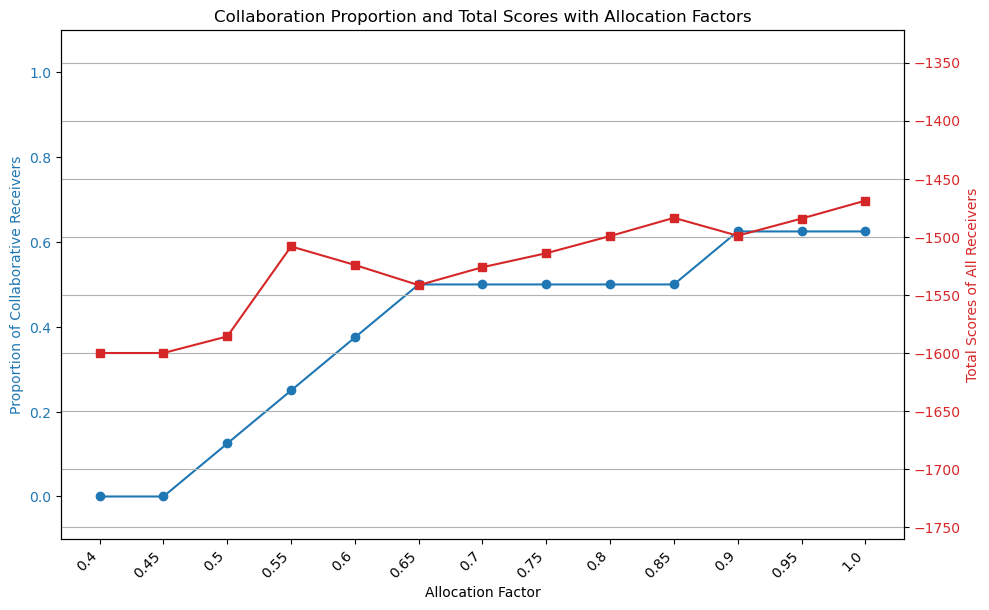

In [103]:
original_tw = (6, 8) 
detail_results = {}
stat_scores = {}
stat_count_collaboration_receivers = {}
stat_prop_collaboration_receivers = {}
for run_folder in run_instance_folders:
    print(f"Analyzing run instance folder: {run_folder}")
    receiver_file_path = os.path.join(output_path, run_folder, 'receivers.xml.gz')
    if not os.path.exists(receiver_file_path):
        raise Exception("Missing receiver file.")
    
     # Original time window
    result = count_collaborative_receivers(receiver_file_path, original_tw)
    
    # Store results
    detail_results[run_folder] = result
    stat_scores[run_folder] = result['total_score']
    stat_count_collaboration_receivers[run_folder] = result['count_collaborative']
    stat_prop_collaboration_receivers[run_folder] = result['count_collaborative'] / result['total_receivers'] if result['total_receivers'] > 0 else 0

# plot_collaboration_stat(factor_type='penalty',
#                         prop_collaborators_dict=stat_prop_collaboration_receivers,
#                         stat_total_scores_dict=stat_scores,
#                         output_path=None)
plot_collaboration_stat(factor_type='allocation',
                        prop_collaborators_dict=stat_prop_collaboration_receivers,
                        stat_total_scores_dict=stat_scores,
                        output_path=None)

In [44]:
stat_scores

{'0.001-200': -1346.3733180219074,
 '0.003-200': -1403.1865585797973,
 '0.005-200': -1442.14382250386,
 '0.01-200': -1504.1314816,
 '0.02-200': -1538.3325508,
 '0.03-200': -1548.1008899522453,
 '0.035-200': -1600.0,
 '0.04-200': -1600.0,
 '0.05-200': -1600.0}

# Test

In [42]:
''' Use lxml to read the output receiver.xml file '''
test_receiver_file_path = output_path + run_instance_folders[1] + '/receivers.xml.gz'
print(test_receiver_file_path)

original_tw = (6,8) # this means the original (non-collaborative receivers') time window is from 6am to 8am

output/specificCarrierReceiverShapleyExample/0.003-200/receivers.xml.gz


In [43]:
count_collaborative_receivers(test_receiver_file_path, original_tw)

{'collaborative_receivers': [{'id': 'collaborativeReceiver_0_to_1',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -166.15877785900867},
  {'id': 'collaborativeReceiver_1_to_2',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -180.97719941864523},
  {'id': 'collaborativeReceiver_2_to_3',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -180.64825903939058},
  {'id': 'collaborativeReceiver_3_to_4',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -186.43520027748244},
  {'id': 'collaborativeReceiver_4_to_5',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -175.34612814875322},
  {'id': 'collaborativeReceiver_5_to_6',
   'time_window': (6, 9),
   'time_window_str': '06:00:00 - 09:00:00',
   'score': -171.96251744054524},
  {'id': 'collaborativeReceiver_6_to_7',
   'time_window': (6, 9),
   'time_window_str': '06:00:0